# 08. Robustness, uncertainty, and final paper outputs

This notebook reproduces the post-specification robustness analyses and final paper-facing policy outputs. It never overwrites the frozen empirical-Bayes main policy artifact. Behavioral-parameter ranges condition on selected calendars and exclude calendar-selection, PPML-estimation, planning-origin, and historical-state uncertainty.

**Inputs:** the empirical-Bayes policy artifact from Notebook 06. **Outputs:** final policy tables, Figures 2–3, robustness summaries, and fixed-calendar behavioral-parameter uncertainty.

In [1]:
from pathlib import Path
import pandas as pd
import sys

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [CURRENT_DIR, *CURRENT_DIR.parents] if (p / 'pyproject.toml').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run from the repository or notebooks directory.')
EB_VERSION = 'empirical_bayes_price_consistent'
MAIN_ARTIFACT = PROJECT_ROOT / 'artifacts' / 'policy' / EB_VERSION / 'policy_optimization.pkl'
ROBUSTNESS_DIR = PROJECT_ROOT / 'results' / EB_VERSION / 'robustness'
assert MAIN_ARTIFACT.exists(), 'EB main policy artifact is missing. Run Notebook 06 first.'
ROBUSTNESS_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

## Diagnostics / validation

### Optional Figure 2 zoom: reimbursement share 0.50?1.00

This view defers until the Task-8 reporting grid exists.

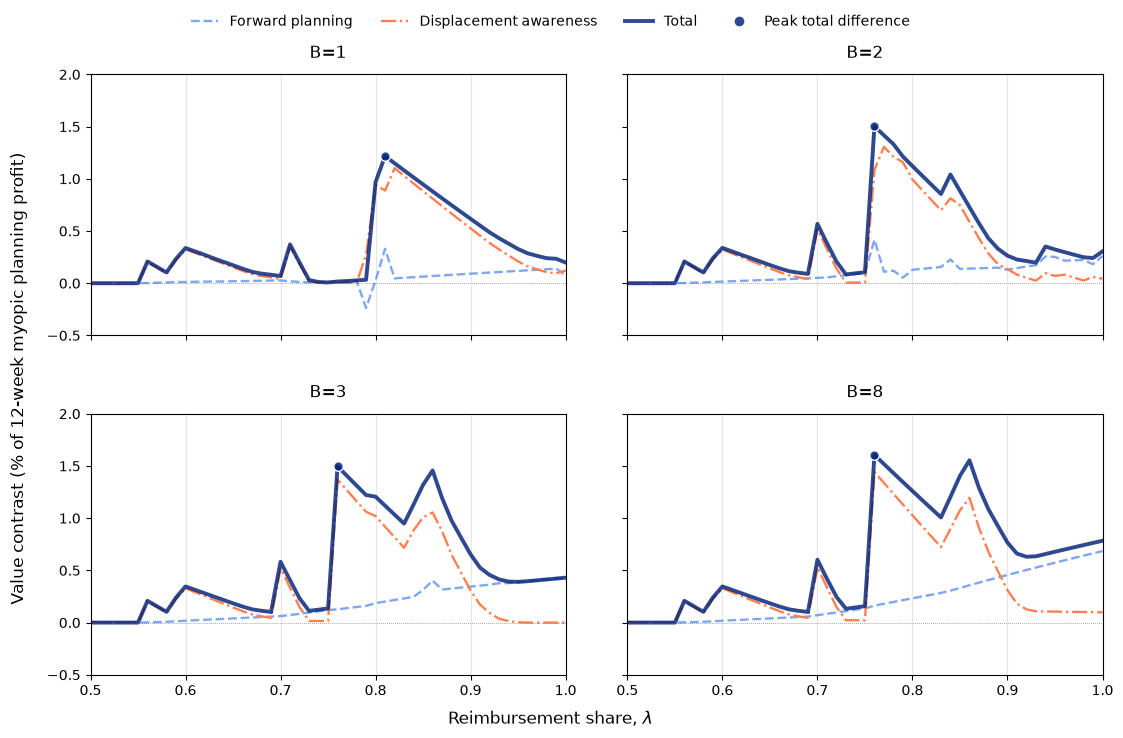

Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\empirical_bayes_price_consistent\figures\three_policy_components_by_capacity_lambda_050_to_100.png


In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

TABLE_DIR = PROJECT_ROOT / 'results' / EB_VERSION / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'results' / EB_VERSION / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not (TABLE_DIR / 'task8_three_policy_reporting_grid.csv').is_file():
    print('Deferred optional 12-week zoom until Task-8 reporting exists.')
else:
    zoom_grid = pd.read_csv(TABLE_DIR / 'task8_three_policy_reporting_grid.csv')
    zoom_grid = zoom_grid.loc[
        zoom_grid['specification'].eq('main')
        & zoom_grid['reimbursement_share'].between(0.50, 1.00)
    ].copy()
    if zoom_grid.empty:
        raise RuntimeError('No main-specification Task-8 rows are available for the requested zoom.')

    components = [
        ('delta_plan_pct', r'$\Delta^{\mathrm{plan}}$', '#6494EDD3', '--', 1.7),
        ('delta_disp_pct', r'$\Delta^{\mathrm{disp}}$', 'coral', '-.', 1.7),
        ('delta_total_pct', r'$\Delta^{\mathrm{total}}$', '#022278D2', '-', 2.8),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6), sharex=True, sharey=True)
    for ax, capacity in zip(axes.flat, [1, 2, 3, 8]):
        group = zoom_grid.loc[zoom_grid['capacity'].eq(capacity)].sort_values('reimbursement_share')
        if group.empty:
            raise RuntimeError(f'Missing B={capacity} from the Task-8 reporting grid.')
        for column, _label, color, linestyle, linewidth in components:
            ax.plot(group['reimbursement_share'], group[column], color=color, linestyle=linestyle, linewidth=linewidth)
        # Select the marker by absolute ?total; plot its 12-week-normalized height.
        peak = group.loc[group['delta_total'].idxmax()]
        ax.scatter(peak['reimbursement_share'], peak['delta_total_pct'], s=48, color='#022278D2', edgecolor='white', linewidth=1.0, zorder=5)
        ax.axhline(0, color='0.45', linewidth=0.55, linestyle=':')
        ax.set_title(f'B={capacity}', pad=12)
        ax.set_xlim(0.50, 1.00)
        ax.set_xticks(np.arange(0.50, 1.01, 0.10))
        ax.set_ylim(-0.5, 2)
        ax.grid(axis='x', color='0.90', linewidth=0.8)

    fig.supxlabel(r'Reimbursement share, $\lambda$', y=0.04)
    fig.supylabel('Value contrast (% of 12-week myopic planning profit)', x=0.03)
    legend_handles = [
        Line2D([0], [0], color=color, linestyle=linestyle, linewidth=linewidth, label=label)
        for _column, label, color, linestyle, linewidth in components
    ] + [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#022278D2', markeredgecolor='white', markersize=8, label='Absolute-total peak')
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.995))
    fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.11, hspace=0.30, wspace=0.13)
    zoom_path = FIGURE_DIR / 'three_policy_components_by_capacity_lambda_050_to_100.png'
    fig.savefig(zoom_path, dpi=300)
    display(fig)
    plt.close(fig)
    print(f'Saved: {zoom_path}')

### Optional Figure 2 zoom: 48-week same-horizon normalization

This diagnostic view defers until the same-horizon reporting grid exists.

In [ ]:
same_horizon_grid_path = PROJECT_ROOT / 'results' / EB_VERSION / 'robustness' / 'same_horizon_normalization_full_grid.csv'
if same_horizon_grid_path.is_file():
    import subprocess

    subprocess.run(
        [sys.executable, str(SCRIPTS_DIR / "build_three_policy_48_week_figure.py")],
        cwd=PROJECT_ROOT,
        check=True,
    )
else:
    print('Deferred optional 48-week view until same-horizon reporting exists.')


## Robustness computations and reporting inputs

The first computation reoptimizes pooled-displacement, influential-product, and three-week-cooldown specifications, constructs reporting denominators, and creates final policy figures. It does not refit PPML. The second fits the alternative `product_promotion` PPML profile and reoptimizes the policy grid; it is the longest step. All write only to versioned robustness paths.

In [6]:
# Reoptimize the prespecified robustness cases, construct the 12-week and
# same-horizon 48-week reporting measures, and then build Figures 2–3.
import subprocess

for script_name in ["run_task7_robustness.py", "run_task8_reporting_checks.py", "build_three_policy_figures.py"]:
    subprocess.run([sys.executable, str(SCRIPTS_DIR / script_name)], cwd=PROJECT_ROOT, check=True)


### Three-week cooldown robustness

This reoptimizes all three policies under the stricter `P, 0, 0, 0, P` feasible-calendar rule. It preserves every other frozen empirical-Bayes input and writes only to a separate robustness path.

In [ ]:
# Run the three-week-cooldown feasible-set robustness check.
subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "run_cooldown_3_weeks_robustness.py")],
    cwd=PROJECT_ROOT,
    check=True,
)


In [7]:
# Same-horizon normalization and fixed-calendar behavioral-parameter
# uncertainty. This section neither refits PPML nor reoptimizes calendars.
from run_final_robustness_reporting import run_reporting_robustness

reporting_results = run_reporting_robustness()
same_horizon_grid = reporting_results['same_horizon_grid']
normalization_peaks = reporting_results['same_horizon_peaks']
parent_level_contrasts = reporting_results['fixed_calendar_parent_contrasts']
uncertainty_peaks = reporting_results['fixed_calendar_summary']
print(f"Completed normalization and fixed-calendar uncertainty in {reporting_results['runtime_seconds']:.1f} seconds.")

Completed A and C in 411.3 seconds.


In [8]:
# B: execute the expensive PPML fit, common-origin profile, and full reoptimization in-kernel.
# It reuses final behavioral draws/actions and writes only under robustness paths.
from run_alternative_ppml_robustness import run_alternative_ppml_robustness

alternative_results = run_alternative_ppml_robustness()
alternative_prediction_grid = alternative_results['predictions']
alternative_weekly_profile = alternative_results['weekly_profile_table']
alternative_policy_grid = alternative_results['full_grid']
alternative_summary = alternative_results['summary']
alternative_vs_main = alternative_results['comparison']
display(alternative_summary)
print(f"Completed B in {alternative_results['runtime_seconds']:.1f} seconds.")

,specification,capacity,peak_delta_total,peak_lambda,peak_delta_plan,peak_delta_disp,displacement_share_at_peak,piM_transitions,piN_transitions,piD_transitions,piM_transition_locations,piN_transition_locations,piD_transition_locations
0,alternative_product_promotion,1,1124.450542,0.90,24.583471,1099.867071,0.978137,5,6,9,0.82|0.86|0.87|0.90|0.93,0.82|0.86|0.87|0.88|0.90|0.93,0.84|0.86|0.88|0.89|0.90|0.91|0.92|0.93|1.00
1,alternative_product_promotion,2,1624.578680,0.87,17.252643,1607.326038,0.989380,9,9,13,0.82|0.86|0.87|0.88|0.89|0.90|0.91|0.93|0.95,0.82|0.86|0.87|0.88|0.89|0.90|0.91|0.93|0.95,0.84|0.86|0.88|0.89|0.90|0.91|0.92|0.94|0.95|0...
2,alternative_product_promotion,3,1822.135862,0.88,62.939124,1759.196738,0.965459,7,8,9,0.82|0.86|0.87|0.88|0.89|0.90|0.91,0.82|0.86|0.87|0.88|0.89|0.90|0.91|0.95,0.84|0.86|0.88|0.89|0.90|0.93|0.94|0.95|0.96
3,alternative_product_promotion,8,1921.713062,0.88,98.083032,1823.630030,0.948961,5,5,9,0.82|0.86|0.87|0.88|0.90,0.82|0.86|0.87|0.88|0.90,0.84|0.86|0.88|0.90|0.93|0.94|0.95|0.97|1.00


Completed B in 867.9 seconds.


## A. Same-horizon normalization

The 12-week myopic-planning-profit percentage remains the operational primary measure. The 48-week percentage is reported only as a same-horizon normalization.

In [9]:
display(normalization_peaks)

,reimbursement_share,capacity,myopic_planning_profit_12w,myopic_profit_48w,delta_plan,delta_plan_pct_myopic_planning_12w,delta_plan_pct_myopic_same_horizon_48w,delta_disp,delta_disp_pct_myopic_planning_12w,delta_disp_pct_myopic_same_horizon_48w,delta_total,delta_total_pct_myopic_planning_12w,delta_total_pct_myopic_same_horizon_48w
0,0.92,1,79000.160523,292298.211733,-15.565868,-0.019704,-0.005325,889.311775,1.125709,0.304248,873.745907,1.106005,0.298923
1,0.87,2,77101.807287,290155.377286,18.225257,0.023638,0.006281,1436.768008,1.863469,0.495172,1454.993265,1.887107,0.501453
2,0.88,3,77114.402456,290270.795431,158.017057,0.204913,0.054438,1421.776707,1.843724,0.489810,1579.793764,2.048636,0.544248
3,0.88,8,76859.816026,290179.918729,89.734137,0.116750,0.030924,1583.211933,2.059870,0.545597,1672.946069,2.176620,0.576520


## B. Alternative demand-model robustness

This uses the simpler `product_promotion` PPML profile but retains the frozen behavioral draws, actions, economics, initialization, horizon, and optimizer.

In [10]:
display(alternative_summary)

,specification,capacity,peak_delta_total,peak_lambda,peak_delta_plan,peak_delta_disp,displacement_share_at_peak,piM_transitions,piN_transitions,piD_transitions,piM_transition_locations,piN_transition_locations,piD_transition_locations
0,alternative_product_promotion,1,1124.450542,0.90,24.583471,1099.867071,0.978137,5,6,9,0.82|0.86|0.87|0.90|0.93,0.82|0.86|0.87|0.88|0.90|0.93,0.84|0.86|0.88|0.89|0.90|0.91|0.92|0.93|1.00
1,alternative_product_promotion,2,1624.578680,0.87,17.252643,1607.326038,0.989380,9,9,13,0.82|0.86|0.87|0.88|0.89|0.90|0.91|0.93|0.95,0.82|0.86|0.87|0.88|0.89|0.90|0.91|0.93|0.95,0.84|0.86|0.88|0.89|0.90|0.91|0.92|0.94|0.95|0...
2,alternative_product_promotion,3,1822.135862,0.88,62.939124,1759.196738,0.965459,7,8,9,0.82|0.86|0.87|0.88|0.89|0.90|0.91,0.82|0.86|0.87|0.88|0.89|0.90|0.91|0.95,0.84|0.86|0.88|0.89|0.90|0.93|0.94|0.95|0.96
3,alternative_product_promotion,8,1921.713062,0.88,98.083032,1823.630030,0.948961,5,5,9,0.82|0.86|0.87|0.88|0.90,0.82|0.86|0.87|0.88|0.90,0.84|0.86|0.88|0.90|0.93|0.94|0.95|0.97|1.00


## Main paper outputs

### Table 4 ? Robustness peak locations and normalized magnitudes

Each cell reports the reimbursement share maximizing the total contrast and the associated contrast as a percentage of that specification?s own 12-week myopic planning profit.

In [11]:
from build_robustness_peak_table import build_robustness_peak_table

robustness_peak_long, robustness_peak_table = build_robustness_peak_table()
table4_path = TABLE_DIR / "robustness_peak_location_and_magnitude.csv"
pd.testing.assert_frame_equal(
    robustness_peak_table.reset_index(drop=True),
    pd.read_csv(table4_path).reset_index(drop=True),
    check_dtype=False,
)
paper_tables = build_paper_tables()
robustness_peak_table = paper_tables["table4"]
display(robustness_peak_table)
print(
    'Table note: Each cell reports peak reimbursement share \u03bb / peak \u0394total '
    'as a percentage of specification-specific 12-week myopic planning profit.'
)

# Structural checks: exact maximizers, matched peak percentages, and one own
# denominator per specification/capacity cell were asserted by the builder.
assert robustness_peak_long.groupby(['specification', 'capacity']).size().eq(1).all()
assert robustness_peak_long['myopic_planning_profit_12w'].gt(0).all()

from IPython.display import Markdown
peak_min = robustness_peak_long['peak_lambda'].min()
peak_max = robustness_peak_long['peak_lambda'].max()
magnitude_min = robustness_peak_long['peak_delta_total_pct'].min()
magnitude_max = robustness_peak_long['peak_delta_total_pct'].max()
display(Markdown(
    f'**Interpretation.** Across these specifications, peak reimbursement shares range from '
    f'{peak_min:.2f} to {peak_max:.2f}, placing every maximum in a similar '
    f'high-reimbursement region. In contrast, specification-normalized peak contrasts range '
    f'from {magnitude_min:.2f}% to {magnitude_max:.2f}%, showing materially greater sensitivity '
    f'in magnitude than in peak location.'
))

# Behavioral-parameter uncertainty remains conditional on the selected calendars.
display(uncertainty_peaks)

,capacity,reimbursement_share,component,p05,p50,p95,label,bootstrap_parents
0,1,0.92,delta_plan,-56.556822,-16.412869,26.132122,behavioral-parameter uncertainty conditional o...,1000
1,1,0.92,delta_disp,266.022950,880.930550,1575.074589,behavioral-parameter uncertainty conditional o...,1000
2,1,0.92,delta_total,249.699122,865.769874,1576.807620,behavioral-parameter uncertainty conditional o...,1000
3,2,0.87,delta_plan,-20.467985,17.951164,57.460587,behavioral-parameter uncertainty conditional o...,1000
4,2,0.87,delta_disp,48.037805,1137.803587,4204.984788,behavioral-parameter uncertainty conditional o...,1000
5,2,0.87,delta_total,75.658759,1163.109813,4236.709575,behavioral-parameter uncertainty conditional o...,1000
6,3,0.88,delta_plan,75.022217,154.629106,245.161662,behavioral-parameter uncertainty conditional o...,1000
7,3,0.88,delta_disp,430.836928,1296.620957,2689.968435,behavioral-parameter uncertainty conditional o...,1000
8,3,0.88,delta_total,580.622585,1456.030805,2891.319035,behavioral-parameter uncertainty conditional o...,1000
9,8,0.88,delta_plan,42.049244,89.210930,141.433138,behavioral-parameter uncertainty conditional o...,1000


## Main paper outputs

### Figure 2 ? Policy-value contrasts by capacity

The figure uses the 48-week common-horizon myopic-profit denominator and the absolute-total peak convention.

In [1]:
from IPython.display import Image, display
import subprocess

TABLE_DIR = PROJECT_ROOT / "results" / EB_VERSION / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / EB_VERSION / "figures"

# Canonical 48-week Figure 2 export and inline display.
subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "build_three_policy_48_week_figure.py")],
    cwd=PROJECT_ROOT,
    check=True,
)
figure2_path = FIGURE_DIR / "three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.png"
figure2_pdf_path = figure2_path.with_suffix(".pdf")
if not figure2_path.is_file() or not figure2_pdf_path.is_file():
    raise FileNotFoundError("Figure 2 export did not complete.")
display(Image(filename=str(figure2_path)))


NameError: name 'PROJECT_ROOT' is not defined

### Table 3 ? Capacity-specific absolute total-contrast maxima

The displayed main-specification summary is the exact Task-8 export.

In [ ]:
from build_paper_tables import build_paper_tables

paper_tables = build_paper_tables()
table3 = paper_tables["table3"]
if not table3["B"].tolist() == [1, 2, 3, 8]:
    raise AssertionError("Table 3 does not have the canonical capacity rows.")
display(table3)


In [2]:
reporting_grid = pd.read_csv(TABLE_DIR / 'task8_three_policy_reporting_grid.csv')
additivity_error = (reporting_grid['delta_plan'] + reporting_grid['delta_disp'] - reporting_grid['delta_total']).abs().max()
assert additivity_error <= 1e-8, additivity_error
figure_peak = reporting_grid.loc[reporting_grid.groupby(['specification', 'capacity'])['delta_total'].idxmax()]
main_peaks = figure_peak.loc[figure_peak['specification'].eq('main')].sort_values('capacity')
print('Decomposition identity: PASS')
print(f'Maximum absolute error: {additivity_error:.2e}')
display(main_peaks[['capacity', 'reimbursement_share', 'delta_total', 'delta_total_pct']])

NameError: name 'pd' is not defined

### Table 5 ? Behavioral uncertainty conditional on selected calendars

In [ ]:
paper_tables = build_paper_tables()
table5 = paper_tables["table5"]
table5_path = ROBUSTNESS_DIR / "fixed_calendar_behavioral_uncertainty_peak_summary.csv"
pd.testing.assert_frame_equal(
    table5.reset_index(drop=True),
    pd.read_csv(table5_path).reset_index(drop=True),
    check_dtype=False,
    check_exact=False,
    rtol=0.0,
    atol=1e-12,
)
display(table5)


## Diagnostics / validation

### B=2 policy-switching rug (not a manuscript figure)

In [ ]:
rug_path = FIGURE_DIR / "three_policy_switching_rug_B2.png"
if rug_path.is_file():
    display(Image(filename=str(rug_path)))
else:
    print("B=2 switching rug is not available; run the policy-figure builder.")


## Paper-output crosswalk

This check records the sole canonical notebook producer and exported location for each principal manuscript object.

In [ ]:
crosswalk_records = [
    {"Paper object": "Table 1 ? Selected products and empirical promotion support", "Canonical notebook": "03_descriptive_analysis", "Section": "Table 1", "Computed object": "paper_product_table", "Exported file(s)": "results/empirical_bayes/tables/paper_product_characteristics.csv/.tex", "required_exports": ["results/empirical_bayes/tables/paper_product_characteristics.csv", "results/empirical_bayes/tables/paper_product_characteristics.tex"]},
    {"Paper object": "Table 2 ? Demand-model predictive performance", "Canonical notebook": "02_demand_estimation", "Section": "Table 2", "Computed object": "table2", "Exported file(s)": "results/final/tables/final_demand_model_comparison.csv", "required_exports": ["results/final/tables/final_demand_model_comparison.csv"]},
    {"Paper object": "Figure 1 ? Empirical promotion support and calibrated post-promotion effects", "Canonical notebook": "05_product_calibration_and_action_support", "Section": "Figure 1", "Computed object": "build_eb_descriptive_figure output", "Exported file(s)": "results/empirical_bayes/figures/paper_promotion_depths_and_model_implied_post_effects.png/.pdf", "required_exports": ["results/empirical_bayes/figures/paper_promotion_depths_and_model_implied_post_effects.png", "results/empirical_bayes/figures/paper_promotion_depths_and_model_implied_post_effects.pdf"]},
    {"Paper object": "Figure 2 ? Policy-value contrasts by capacity", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Figure 2", "Computed object": "build_three_policy_48_week_figure output", "Exported file(s)": "results/empirical_bayes_price_consistent/figures/three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.png/.pdf", "required_exports": ["results/empirical_bayes_price_consistent/figures/three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.png", "results/empirical_bayes_price_consistent/figures/three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.pdf"]},
    {"Paper object": "Table 3 ? Capacity-specific absolute total-contrast maxima", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Table 3", "Computed object": "table3", "Exported file(s)": "paper/tables/table3_main_policy_peaks.tex", "required_exports": ["paper/tables/table3_main_policy_peaks.tex"]},
    {"Paper object": "Table 4 ? Robustness peak locations", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Table 4", "Computed object": "robustness_peak_table", "Exported file(s)": "paper/tables/table4_robustness_peaks.tex", "required_exports": ["paper/tables/table4_robustness_peaks.tex"]},
    {"Paper object": "Table 5 ? Behavioral uncertainty conditional on selected calendars", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Table 5", "Computed object": "table5", "Exported file(s)": "paper/tables/table5_behavioral_uncertainty.tex", "required_exports": ["paper/tables/table5_behavioral_uncertainty.tex"]},
]
for record in crosswalk_records:
    record["Current manuscript dependency"] = True
    record["Exact output agreement"] = "PASS" if all((PROJECT_ROOT / item).is_file() for item in record["required_exports"]) else "FAIL"
crosswalk = pd.DataFrame(crosswalk_records).drop(columns="required_exports")
if not crosswalk["Exact output agreement"].eq("PASS").all():
    raise FileNotFoundError("One or more principal paper outputs are missing; rerun their canonical producer.")
display(crosswalk)
